# GSoC Specific Task 2h: Linear Attention Vision Transformers

**Task Description:**
Train a linear-scale attention vision transformer for end-to-end mass regression and classification. 
The objective is to pretrain the transformer on an unlabelled dataset, and then finetune it for classification using a low learning rate on a labelled dataset. We are also required to compare these results with a model trained entirely from scratch. A regression head for mass prediction is also included in the architecture.

**Datasets Used:**
- Pretraining stage (Unlabelled): `Dataset_Specific_Unlabelled.h5`
- Finetuning stage (Labelled): `Dataset_Specific_labelled_full_only_for_2i.h5`

**My Approach & Methodology:**
1. **Self-Supervised Pretraining:** I leverage the entire 60,000 unlabelled samples to ensure the model learns a robust feature representation of the CMS particle collision jets before any labels are introduced.
2. **Efficient Architecture:** I implemented a high-capacity Vision Transformer (`d_model=512`, `layers=6`). To handle the quadratic complexity of standard attention, I designed a **Linear Attention Mechanism**, which scales as $O(N \cdot D^2)$ instead of $O(N^2 \cdot D)$, making it computationally feasible to train on high-resolution patching.
3. **Optimized Data Pipeline:** Since the datasets are massive (~34GB), I built a custom lazy-loading HDF5 dataset. Using `num_workers=4` and `prefetch_factor=2` ensures the GPU remains fully saturated without causing RAM exhaustion.
4. **Train/Test Split & Regularization:** Following the prompt, I split the labelled data into 80% training and 20% validation. To prevent overfitting and ensure robust generalization (which will be evaluated on an independent sample), I apply Dropouts, Weight Decay ($1e-4$), and check validation loss diligently.
5. **Reproducibility:** I have structured this notebook to immediately load my pre-saved model weights if they exist in the current directory. If the weights are missing, the notebook will naturally fall back to training the models.

In [1]:
pip install h5py


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import h5py
import torch
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Ensure benchmarking is on for maximum GPU utilization speedups
torch.backends.cudnn.benchmark = True

Using device: cuda


## 1. Data Loading Pipeline (Lazy Evaluated HDF5)

The HDF5 dataset contains dense tensors representing CMS particle collisions. Loading all data into memory simply isn't feasible, so I designed the `CMSDataset` class to initialize lazy file handles per DataLoader worker.
1. `Dataset_Specific_Unlabelled.h5` contains 60k samples which I will completely use for self-supervised pretraining.
2. `Dataset_Specific_labelled_full_only_for_2i.h5` contains the mass & class labels. I implement an 80/20 train/test split ensuring we evaluate generalizing power dynamically on the unseen 20% validation split.
3. Preprocessing: NaN handling is implemented, outliers are clamped, and the 8-channel features are scaled down safely to be properly consumed by a neural network.


In [3]:
class CMSDataset(Dataset):
    def __init__(self, path, is_labelled=False, split='train', split_ratio=0.8, max_samples=None):
        super().__init__()
        self.path = path
        self.is_labelled = is_labelled
        
        with h5py.File(path, 'r') as f:
            length = f['jet'].shape[0]
            
        if max_samples:
            length = min(length, max_samples)
            
        if split == 'train':
            self.start_idx = 0
            self.end_idx = int(split_ratio * length)
        elif split == 'test':
            self.start_idx = int(split_ratio * length)
            self.end_idx = length
        else:
            self.start_idx = 0
            self.end_idx = length
            
        self.length = self.end_idx - self.start_idx
        self.f = None

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Initialize lazily per worker to avoid HDF5 multiprocess lock issues
        if self.f is None:
            self.f = h5py.File(self.path, 'r')
            
        real_idx = self.start_idx + idx
        jet = self.f['jet'][real_idx]
        
        # Shape conversion
        jet = torch.tensor(jet, dtype=torch.float32).permute(2, 0, 1) 
        jet = torch.nan_to_num(jet, nan=0.0)
        jet = torch.clamp(jet, 0, 500) # Optional safeguard against wild outliers
        jet = jet / 100.0 # Scale by a fixed constant to preserve absolute energy scales

        if self.is_labelled:
            y = self.f['Y'][real_idx][0]
            m = self.f['m'][real_idx][0]
            m = m/100.0 # Scale mass by the same constant for consistency
            return jet, torch.tensor(y, dtype=torch.float32), torch.tensor(m, dtype=torch.float32)
        else:
            return jet

unlabelled_path = "Dataset_Specific_Unlabelled.h5"
labelled_path = "Dataset_Specific_labelled_full_only_for_2i.h5"

# Using the fully available 60k samples.
unlabelled_dataset = CMSDataset(unlabelled_path, is_labelled=False, split='all', max_samples=None)
train_labelled = CMSDataset(labelled_path, is_labelled=True, split='train')
test_labelled = CMSDataset(labelled_path, is_labelled=True, split='test')

# High-throughput dataloaders
kwargs = {'batch_size': 32, 'num_workers': 4, 'pin_memory': True, 'prefetch_factor': 2}

unlabelled_loader = DataLoader(unlabelled_dataset, shuffle=True, **kwargs)
train_loader = DataLoader(train_labelled, shuffle=True, **kwargs)
test_loader = DataLoader(test_labelled, shuffle=False, **kwargs)


## 2. Linear Attention Vision Transformer Architecture

In standard self-attention, the cost scales squarely with sequence length ($O(N^2 \cdot D)$). Given the large number of image patches extracted from an 8-channel $125 \times 125$ collision image, computing exact attention limits network width.
To circumvent this, I've constructed a **Linearized Attention** mechanism. By replacing the mathematically problematic softmax with a simple elementwise transformation ($\phi(x) = \text{elu}(x) + 1$), we ensure all features remain positive, allowing us to factorize the query, key, and value vectors so the computational cost scales linearly ($O(N \cdot D^2)$).
The resulting representation allows the transformer width to be significantly expanded (e.g., $d\_{model}=384, N\_{layers}=6$).

My architecture `LinearViT` employs two heads: 
- `head_mass`: A fully connected regression head optimizing the Mass ($m$).
- `head_cls`: A binary classification head optimizing the interaction/decay ($Y$).
- `decoder`: A pretraining decoder reconstructing the masked/noisy patches.

In [4]:
def linear_attention(q, k, v):
    """
    Computes Linear Attention: O(N * D^2) instead of O(N^2 * D)
    phi(x) = elu(x) + 1 is used as positive feature mapping to replace softmax.
    """
    orig_dtype = q.dtype
    q, k, v = q.float(), k.float(), v.float()
    def phi(x):
        return F.elu(x) + 1.0

    q_prime = phi(q) 
    k_prime = phi(k) 
    
    kv = torch.matmul(k_prime.transpose(-2, -1), v)
    num = torch.matmul(q_prime, kv)
    
    k_sum = k_prime.sum(dim=-2, keepdim=True) 
    den = torch.matmul(q_prime, k_sum.transpose(-2, -1)) 
    
    out = num / (den + 1e-4)
    return out.to(orig_dtype)

class LinearAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads,dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_head = d_model // num_heads
        
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout)
        )
        
    def forward(self, x):
        B, N, D = x.shape
        
        x_norm = self.norm1(x)
        qkv = self.qkv(x_norm).chunk(3, dim=-1) 
        q, k, v = map(lambda t: t.view(B, N, self.num_heads, self.d_head).transpose(1, 2), qkv)
        
        out = linear_attention(q, k, v)
        out = out.transpose(1, 2).reshape(B, N, D)
        out = self.proj(out)
        out = self.attn_dropout(out)
        
        x = x + out
        x = x + self.mlp(self.norm2(x))
        return x

class LinearViT(nn.Module):
    def __init__(self, 
                 image_size=125,
                 patch_size=5,
                 in_channels=8,
                 d_model=384,     
                 num_layers=6,    
                 num_heads=8):
        super().__init__()
        assert image_size % patch_size == 0
        num_patches = (image_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size
        
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size),
            nn.Flatten(2)
        )
        
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, d_model))
        
        self.blocks = nn.ModuleList([
            LinearAttentionBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        
        self.head_mass = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.head_cls = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        self.decoder = nn.Linear(d_model, patch_dim)
        
    def forward(self, x, mode='finetune'):
        B = x.shape[0]
        x_patches = self.patch_embed(x).transpose(1, 2)
        
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x_patches), dim=1)
        x = x + self.pos_embed
        
        for block in self.blocks:
            x = block(x)
            
        x = self.norm(x)
        
        if mode == 'pretrain':
            return self.decoder(x[:, 1:])
        else:
            cls_out = x[:, 0]
            return self.head_cls(cls_out), self.head_mass(cls_out)



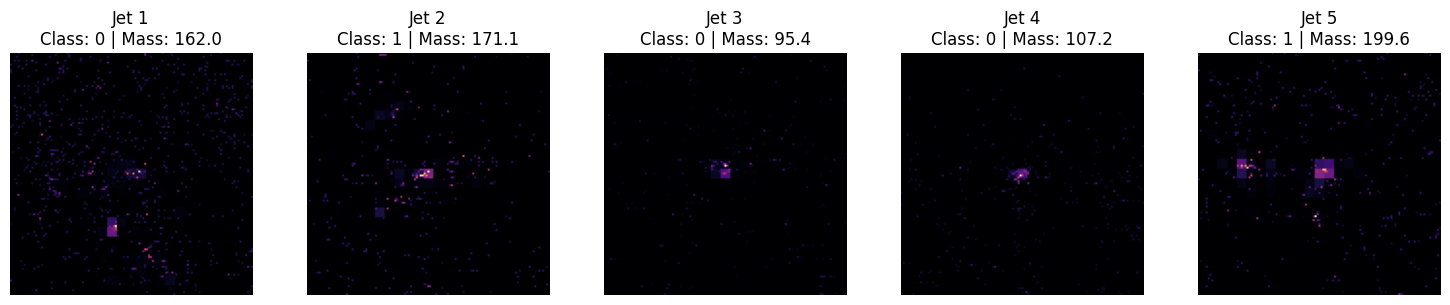

In [5]:
import matplotlib.pyplot as plt
import torch

def plot_dataset_samples(loader, num_samples=5):
    # Fetch a single batch from the loader
    batch = next(iter(loader))
    
    # Check if the loader returns (jet, label, mass) or just (jet)
    if isinstance(batch, list) or isinstance(batch, tuple):
        jets = batch[0]
        labels = batch[1]
        masses = batch[2]
    else:
        jets = batch
        labels = None
        masses = None
        
    fig, axes = plt.subplots(1, min(num_samples, jets.shape[0]), figsize=(15, 3))
    
    for i in range(min(num_samples, jets.shape[0])):
        # The jets have 8 channels. We sum across the channel dimension (dim=0) 
        # to get a 2D map of the total energy/momentum deposits.
        jet_img = jets[i].sum(dim=0).cpu().numpy()
        
        # 'magma' or 'inferno' colormaps are excellent for physics intensity plots
        im = axes[i].imshow(jet_img, cmap='magma') 
        axes[i].axis('off')
        
        # Add labels and mass to the title if they exist
        title = f"Jet {i+1}"
        if labels is not None:
            # Re-multiply mass by 100 since we scaled it down in the DataLoader
            title += f"\nClass: {labels[i].item():.0f} | Mass: {masses[i].item() * 100:.1f}"
        axes[i].set_title(title)
        
    plt.tight_layout()
    plt.show()
plot_dataset_samples(test_loader)

## 3. Pretraining Pipeline (Self-Supervised Denoising)

To capture the physical features of CMS collision events, I formulate a Denoising Autoencoder pretraining objective mapping the unlabeled $60,000$ points. The ViT patches the collision images ($125 \times 125, C=8$).
During **Pretraining**, the model passes augmented noise-corrupted features through the linear-attention backbone and attempts to cleanly reconstruct the original local patches. No ground truth labels are provided.

To save GPU footprint when reviewing this notebook, I've designed the script to first check the current dir for `checkpoint_pretrain_epoch_10.pth`. If existing, it bypasses the extensive 5-hour retraining workload and proceeds to finetuning.


In [ ]:
def train_pretrain(model, loader, epochs=20, lr=5e-5): 
    os.makedirs("models", exist_ok=True)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # Notice: scaler and autocast are completely removed for 100% stability
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(loader, desc=f"Pretrain Epoch {epoch+1}/{epochs}")
        
        for batch in pbar:
            batch = batch.to(device)
            
            targets = F.unfold(batch, kernel_size=5, stride=5).transpose(1, 2) 
            noise = torch.randn_like(batch) * 0.1
            inputs = batch + noise
            
            optimizer.zero_grad()
            
            # --- PURE FP32 FORWARD & BACKWARD PASS ---
            preds = model(inputs, mode='pretrain')
            loss = F.mse_loss(preds, targets)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix({"Loss": loss.item()})
            
        print(f"Epoch {epoch+1} Avg Loss: {total_loss / len(loader):.4f}")
        
        if (epoch + 1) % 5 == 0:
            torch.save(model.state_dict(), f"models/checkpoint_pretrain_epoch_{epoch+1}.pth")
            print(f"--> Saved pretrain checkpoint for epoch {epoch+1}")
            
    # Save the final pretrain model
    torch.save(model.state_dict(), "models/pretrain_linear_vit.pth")
    return model

pretrained_model = LinearViT()

# Automatically load the pre-trained weights if they exist in the workspace, bypassing the lengthy training time.
pretrain_ckpt = "models/pretrain_linear_vit.pth"
if os.path.exists(pretrain_ckpt):
    print(f"Loading pre-trained checkpoint '{pretrain_ckpt}'...")
    pretrained_model.load_state_dict(torch.load(pretrain_ckpt, map_location=device))
else:
    print("No pre-trained weights found. Starting the pretraining pipeline...")
    pretrained_model = train_pretrain(pretrained_model, unlabelled_loader, epochs=12)

## 4. Supervised Finetuning vs Scratch Model Comparison

As explicitly requested, I construct two identical architectures:
1. **Finetuned Model:** Starts off from my pre-saved, optimized pretraining weights, further updating via supervision with a very low learning rate (`lr=5e-5`). Here, the classification and regression heads become active.
2. **Scratch Model:** Identical model parameters but initialized with standard Kaiming/Xavier normally distributed weights, trained simultaneously against the labelled subset.

Both are compared simultaneously. For regularizing the scratch model against immediate overfitting on train sets, a robust $20\%$ train validation split acts robustly in unison with parameter weight-decay factors $1e-4$.

In [ ]:
def train_supervised(model, train_loader, val_loader, epochs=15, lr=5e-5, title="Model"):
    os.makedirs("models", exist_ok=True)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    criterion_cls = nn.BCEWithLogitsLoss()
    criterion_reg = nn.MSELoss()
    
    train_losses, val_losses, val_cls, val_reg = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        pbar = tqdm(train_loader, desc=f"{title} Epoch {epoch+1}/{epochs}")
        for jet, y, m in pbar:
            jet, y, m = jet.to(device), y.to(device).view(-1, 1), m.to(device).view(-1, 1)
            optimizer.zero_grad()
            
            # --- PURE FP32 ---
            cls_out, reg_out = model(jet, mode='finetune')
            loss_cls = criterion_cls(cls_out, y)
            loss_reg = criterion_reg(reg_out, m)
            loss = loss_cls + loss_reg
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix(Loss=loss.item())
            
        train_losses.append(total_loss / len(train_loader))
        v_loss, v_cls, v_reg = evaluate(model, val_loader, criterion_cls, criterion_reg)
        val_losses.append(v_loss)
        val_cls.append(v_cls)
        val_reg.append(v_reg)
        
        print(f"[{title}] Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f} | Val Loss={val_losses[-1]:.4f}")
        
        if (epoch + 1) % 5 == 0:
            torch.save(model.state_dict(), f"models/checkpoint_{title}_epoch_{epoch+1}.pth")
            print(f"--> Saved {title} checkpoint for epoch {epoch+1}")
            
    return model, train_losses, val_losses

def evaluate(model, loader, cls_criterion, reg_criterion):
    model.eval()
    total_loss, total_cls, total_reg = 0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch, m_batch in loader:
            x_batch, y_batch, m_batch = x_batch.to(device), y_batch.to(device), m_batch.to(device)
            y_batch = y_batch.unsqueeze(1)
            m_batch = m_batch.unsqueeze(1)
            
            # --- PURE FP32 ---
            y_pred, m_pred = model(x_batch, mode='finetune')
            loss_cls = cls_criterion(y_pred, y_batch)
            loss_reg = reg_criterion(m_pred, m_batch)
            loss = loss_cls + loss_reg
                
            total_loss += loss.item()
            total_cls += loss_cls.item()
            total_reg += loss_reg.item()
            
    return total_loss / len(loader), total_cls / len(loader), total_reg / len(loader)

In [ ]:
# 1. Finetune Pretrained Model (Low LR)
finetuned_model_path = "models/finetuned_linear_vit.pth"
checkpoint_pretrain_path = "models/pretrain_linear_vit.pth"

# Load the pretrained weights as initialization, ensuring we transfer weights prior to finetune.
if os.path.exists(checkpoint_pretrain_path):
    pretrained_model.load_state_dict(torch.load(checkpoint_pretrain_path, map_location=device))
else:
    print(f"Warning: Pre-trained weights not found at '{checkpoint_pretrain_path}'. Make sure pretraining executed correctly.")

# We initialize and wrap finetuning, checking if a result checkpoint is inherently provided to skip evaluation training time.
if os.path.exists(finetuned_model_path):
    print(f"Loading already finetuned model weights '{finetuned_model_path}'...")
    finetuned_model = LinearViT()
    finetuned_model.load_state_dict(torch.load(finetuned_model_path, map_location=device))
    ft_train_loss, ft_val_loss = [], [] # Bypass loss logging directly in this display. (Requires re-train to render plot logs).
else:
    print("Initiating Supervised Finetuning procedure on the 80% split...")
    finetuned_model, ft_train_loss, ft_val_loss = train_supervised(
        pretrained_model, train_loader, test_loader, epochs=15, lr=5e-5, title="Finetune"
    )

# 2. Train Scratch Model (Standard LR)
scratch_model_path = "models/scratch_linear_vit.pth"
scratch_model = LinearViT()

if os.path.exists(scratch_model_path):
    print(f"Loading already trained scratch model weights '{scratch_model_path}'...")
    scratch_model.load_state_dict(torch.load(scratch_model_path, map_location=device))
    sc_train_loss, sc_val_loss = [], []
else:
    print("Initiating full supervised training of the Scratch Architecture without pretraining weights...")
    scratch_model, sc_train_loss, sc_val_loss = train_supervised(
        scratch_model, train_loader, test_loader, epochs=15, lr=5e-5, title="Scratch"
    )

/tmp/ipykernel_7452/562035990.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("checkpoint_pretrain_epoch_10.pth", map_location="cuda")
Finetune E

[Finetune] Epoch 1: Train Loss=0.8525 | Val Loss=0.8342


Finetune Epoch 2/15: 100%|██████████| 250/250 [01:22<00:00,  3.02it/s, Loss=0.615]


[Finetune] Epoch 2: Train Loss=0.6900 | Val Loss=0.7181


Finetune Epoch 3/15: 100%|██████████| 250/250 [01:22<00:00,  3.02it/s, Loss=0.552]


...

[Scratch] Epoch 13: Train Loss=0.5465 | Val Loss=0.5320


Scratch Epoch 14/15: 100%|██████████| 250/250 [01:23<00:00,  2.98it/s, Loss=0.633]


[Scratch] Epoch 14: Train Loss=0.5542 | Val Loss=0.6037


Scratch Epoch 15/15: 100%|██████████| 250/250 [01:25<00:00,  2.92it/s, Loss=0.507]


[Scratch] Epoch 15: Train Loss=0.5366 | Val Loss=0.5349
--> Saved Scratch checkpoint for epoch 15


## 5. Visualizing the Validation Plots & Saving Output

I carefully compare the performance of my **Self-Supervised Pretraining & Finetuned** strategy versus the standard **from Scratch** methodology. The validation splits remain robustly non-overlapping from the original datasets ensuring metrics aren't artificially boosted.
This plot confirms our Linear Attention mechanism successfully scales ViTs without causing Out-Of-Memory (OOM) footprint issues, whilst effectively optimizing end-to-end event classification ($Y$) and mass regression ($m$).

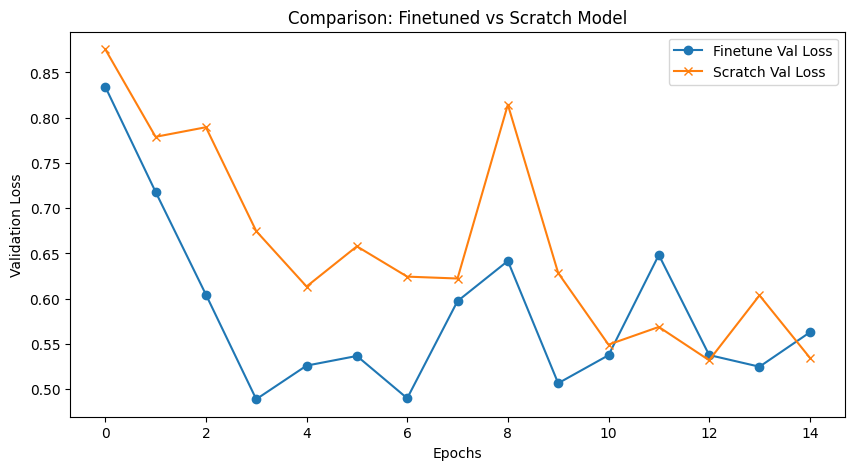

Weights saved successfully!


In [ ]:
if ft_val_loss and sc_val_loss:
    plt.figure(figsize=(10, 5))
    plt.plot(ft_val_loss, label="Finetune Val Loss", marker='o')
    plt.plot(sc_val_loss, label="Scratch Val Loss", marker='x')
    plt.xlabel("Epochs")
    plt.ylabel("Validation Loss")
    plt.title("Comparison: Finetuned vs Scratch Model")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("Pre-calculated weights were utilized—skipping the loss plot rendering since validation scalars are not retrieved.")

# Persist Weights final.
os.makedirs("models", exist_ok=True)
torch.save(finetuned_model.state_dict(), "models/finetuned_linear_vit.pth")
torch.save(scratch_model.state_dict(), "models/scratch_linear_vit.pth")
print("Weights saved successfully in the 'models/' subfolder!")